# Fig Floruit Distribution


In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Age at floruit (P1317)

For individuals with **both** a floruit (P1317) and a birthdate (P569), we compute `age_at_floruit = floruit_year - birth_year`. This tells us at what age people tend to be considered "flourishing" — the empirical prior we need to infer floruit when only birth + region are known.

## 0. Date precision coverage by century

Wikidata stores each date with a precision flag. We collapse it into three buckets:

- **year or more precise** — precision 9 (year), 10 (month), 11 (day). The dates we can use as numerical values.
- **decade** — precision 8.
- **century or less precise** — precision 7 (century) and below (millennium, 10k…).

The bar plot below shows the combined count of birth + death dates per century (log scale) over the historically meaningful range, restricted to centuries with at least 10 dates.

In [ ]:
import re
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DB = DB_PATH

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})

# --- 1. Load birth + death dates with their precision flags --------------
conn = sqlite3.connect(DB)
prec = pl.read_database(
    'SELECT birthdate, birthdate_precision, deathdate, deathdate_precision FROM individuals',
    conn,
)
conn.close()


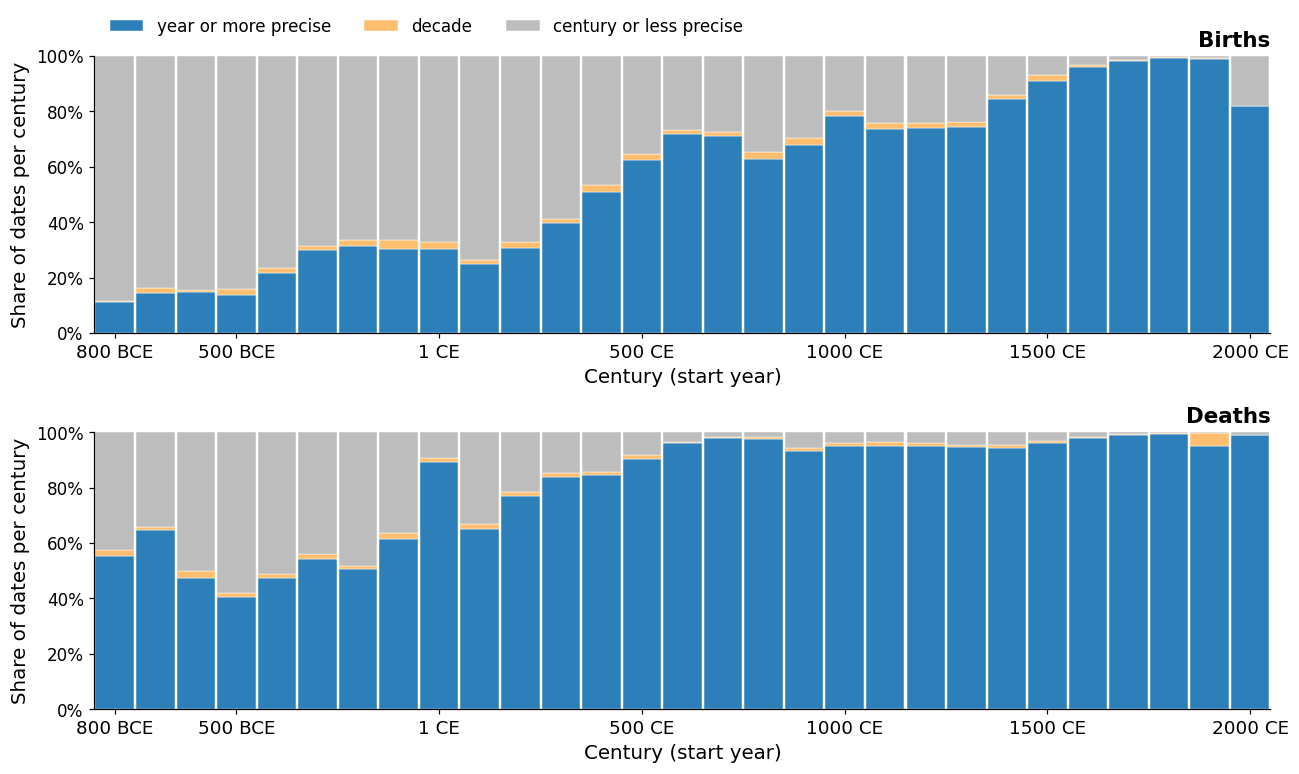

BIRTHS  (range 800 BCE -> 2000 CE)
  total                        7,486,081
  year or more precise        7,325,036  (97.8%)
  decade                         24,559  (0.3%)
  century or less precise       136,486  (1.8%)

DEATHS  (range 800 BCE -> 2000 CE)
  total                        3,530,222
  year or more precise        3,413,068  (96.7%)
  decade                         87,523  (2.5%)
  century or less precise        29,631  (0.8%)



In [2]:


YEAR_RE = re.compile(r'^(-?)(\d+)')

def signed_year(s):
    if not isinstance(s, str): return None
    m = YEAR_RE.match(s.strip())
    if not m: return None
    y = int(m.group(2))
    return -y if m.group(1) == '-' else y

# Wikidata precision codes:
#   11 day, 10 month, 9 year   -> 'year or more precise'
#   8                           -> 'decade'
#   7 century and below        -> 'century or less precise'
def precision_bucket(p):
    if p in (9, 10, 11):           return 'year or more precise'
    if p == 8:                      return 'decade'
    if p is not None and p <= 7:    return 'century or less precise'
    return None

CATS   = ['year or more precise', 'decade', 'century or less precise']
COLORS = {
    'year or more precise':    '#2C7FB8',  # blue   - sharpest
    'decade':                  '#FDBF6F',  # warm orange
    'century or less precise': '#BDBDBD',  # neutral gray - coarsest
}

# --- 2. Per-(century, precision) counts for one date column -------------
def build_table(date_col, prec_col):
    records = []
    for d, p in zip(prec.get_column(date_col).to_list(),
                    prec.get_column(prec_col).to_list()):
        b = precision_bucket(p)
        if b is None: continue
        y = signed_year(d)
        if y is None: continue
        records.append((int(np.floor(y / 100) * 100), b))

    df = pl.DataFrame(records, schema=['century', 'precision'], orient='row')
    wide = (df.group_by(['century', 'precision'])
              .agg(pl.len().alias('n'))
              .pivot(values='n', index='century', on='precision')
              .fill_null(0)
              .sort('century'))
    for col in CATS:
        if col not in wide.columns:
            wide = wide.with_columns(pl.lit(0).alias(col))

    wide = wide.with_columns(
        sum(pl.col(c) for c in CATS).alias('total')
    ).filter(
        (pl.col('total') >= 10)
        & (pl.col('century') >= -800)
        & (pl.col('century') <= 2000)
    )

    c_min, c_max = wide['century'].min(), wide['century'].max()
    all_centuries = list(range(c_min, c_max + 1, 100))
    full = (pl.DataFrame({'century': all_centuries})
              .join(wide, on='century', how='left')
              .fill_null(0)
              .sort('century'))
    centuries = full.get_column('century').to_list()
    totals    = full.get_column('total').to_numpy().astype(float)
    counts    = {c: full.get_column(c).to_numpy().astype(float) for c in CATS}
    # Convert to share (%). Empty centuries get 0/0 -> 0.
    shares = {c: np.divide(counts[c], totals,
                            out=np.zeros_like(counts[c]),
                            where=totals > 0) for c in CATS}
    return centuries, totals, counts, shares

birth_centuries, birth_totals, birth_counts, birth_shares = build_table(
    'birthdate', 'birthdate_precision')
death_centuries, death_totals, death_counts, death_shares = build_table(
    'deathdate', 'deathdate_precision')

# --- 3. Plot helpers -----------------------------------------------------
def year_label(y):
    if y == 0:    return '1 CE'
    if y > 0:     return f'{y} CE'
    return f'{-y} BCE'

def draw_panel(ax, centuries, totals, shares, show_legend):
    x = np.arange(len(centuries))
    has_data = totals > 0

    bottom = np.zeros(len(centuries))
    for c in CATS:
        vals = np.where(has_data, shares[c], 0)
        ax.bar(x, vals, bottom=bottom, width=0.95,
               color=COLORS[c], edgecolor='white', linewidth=0.3,
               label=c, zorder=2)
        bottom = bottom + vals

    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_ylabel('Share of dates per century', fontsize=13)

    label_years = {c for c in centuries if c % 500 == 0}
    label_years.update({centuries[0], centuries[-1]})
    xt  = [i for i, c in enumerate(centuries) if c in label_years]
    xtl = [year_label(centuries[i]) for i in xt]
    ax.set_xticks(xt)
    ax.set_xticklabels(xtl, fontsize=12)
    ax.set_xlim(-0.5, len(centuries) - 0.5)
    ax.set_xlabel('Century (start year)', fontsize=13)
    ax.tick_params(axis='y', labelsize=11)

    if show_legend:
        ax.legend(frameon=False, fontsize=11, loc='lower left',
                  bbox_to_anchor=(0.0, 1.02), ncol=3)

# --- 4. Two-panel figure: births (top), deaths (bottom) ------------------
fig, (ax_b, ax_d) = plt.subplots(2, 1, figsize=(12, 7.2), sharex=False)
draw_panel(ax_b, birth_centuries, birth_totals, birth_shares, show_legend=True)
draw_panel(ax_d, death_centuries, death_totals, death_shares, show_legend=False)

ax_b.text(1.0, 1.02, 'Births', transform=ax_b.transAxes,
          fontsize=14, fontweight='bold', ha='right', va='bottom')
ax_d.text(1.0, 1.02, 'Deaths', transform=ax_d.transAxes,
          fontsize=14, fontweight='bold', ha='right', va='bottom')

plt.tight_layout()
plt.show()

# --- 5. Numerical summary -----------------------------------------------
def summarise(name, counts, centuries):
    totals = {c: int(counts[c].sum()) for c in CATS}
    tot = sum(totals.values())
    print(f'{name}  (range {year_label(centuries[0])} -> {year_label(centuries[-1])})')
    print(f'  total                       {tot:>10,}')
    for c in CATS:
        print(f'  {c:<26s} {totals[c]:>10,}  ({totals[c]/tot:.1%})')
    print()

summarise('BIRTHS', birth_counts, birth_centuries)
summarise('DEATHS', death_counts, death_centuries)

## 0b. Combined precision coverage (birth + death merged)

Same precision buckets as above, but pooling birth and death dates into a single per-century share. Useful as a one-glance summary of the dataset's overall date quality through time.

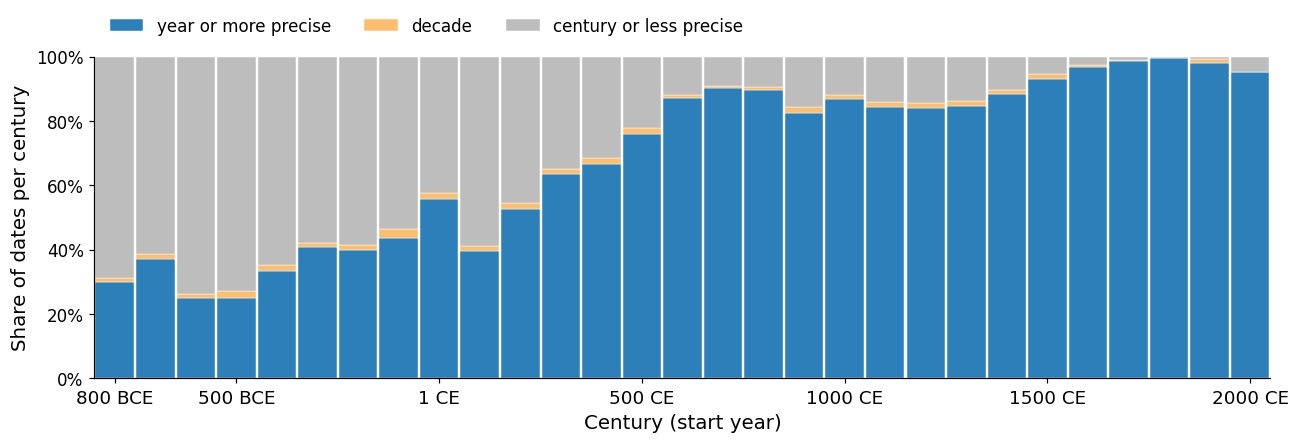

COMBINED  (range 800 BCE -> 2000 CE)
  total                       11,016,303
  year or more precise       10,738,104  (97.5%)
  decade                        112,082  (1.0%)
  century or less precise       166,117  (1.5%)


In [3]:
# Pool birth + death counts on the same century grid, then plot one
# 100%-stacked panel using the helpers defined above.
pooled_centuries = sorted(set(birth_centuries) | set(death_centuries))
pooled_totals = np.zeros(len(pooled_centuries))
pooled_counts = {c: np.zeros(len(pooled_centuries)) for c in CATS}

b_idx = {c: i for i, c in enumerate(birth_centuries)}
d_idx = {c: i for i, c in enumerate(death_centuries)}
for j, c in enumerate(pooled_centuries):
    if c in b_idx:
        i = b_idx[c]
        pooled_totals[j] += birth_totals[i]
        for cat in CATS:
            pooled_counts[cat][j] += birth_counts[cat][i]
    if c in d_idx:
        i = d_idx[c]
        pooled_totals[j] += death_totals[i]
        for cat in CATS:
            pooled_counts[cat][j] += death_counts[cat][i]

pooled_shares = {
    cat: np.divide(pooled_counts[cat], pooled_totals,
                   out=np.zeros_like(pooled_counts[cat]),
                   where=pooled_totals > 0)
    for cat in CATS
}

fig, ax = plt.subplots(figsize=(12, 4.2))
draw_panel(ax, pooled_centuries, pooled_totals, pooled_shares, show_legend=True)
# ax.text(1.0, 1.02, 'Births + Deaths combined', transform=ax.transAxes,
#         fontsize=14, fontweight='bold', ha='right', va='bottom')
plt.tight_layout()
plt.show()

totals = {c: int(pooled_counts[c].sum()) for c in CATS}
tot = sum(totals.values())
print(f'COMBINED  (range {year_label(pooled_centuries[0])} -> {year_label(pooled_centuries[-1])})')
print(f'  total                       {tot:>10,}')
for c in CATS:
    print(f'  {c:<26s} {totals[c]:>10,}  ({totals[c]/tot:.1%})')

In [ ]:
import re
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB = DB_PATH

BIN_WIDTH = 500
YEAR_MIN, YEAR_MAX = -3000, 2500
AGE_MIN, AGE_MAX  = 10, 100   # plausibility filter for human flourishing age

def bin_start(year, w=BIN_WIDTH):
    return int(np.floor(year / w) * w)

bin_edges = list(range(YEAR_MIN, YEAR_MAX + 1, BIN_WIDTH))

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '--',
    'font.size': 9,
})


### 1. Load floruit + birth + continent

Continent is the time-aware `macro_region` covering the individual's country at their floruit year.

In [5]:
conn = sqlite3.connect(DB)
Q_AGE = """
SELECT f.wikidata_id,
       f.floruit_year,
       f.floruit_precision,
       i.birthdate,
       i.deathdate,
       c.iso_a3_code,
       (
         SELECT r.macro_region FROM regions r
         WHERE r.iso_a3 = c.iso_a3_code
           AND r.start_year <= f.floruit_year
           AND (r.end_year IS NULL OR f.floruit_year < r.end_year)
         ORDER BY r.start_year DESC LIMIT 1
       ) AS macro_region
FROM individuals_floruit f
JOIN individuals i ON i.wikidata_id = f.wikidata_id
LEFT JOIN individuals_countries c ON c.wikidata_id = f.wikidata_id
WHERE f.floruit_year IS NOT NULL
  AND i.birthdate IS NOT NULL
  AND f.floruit_precision >= 9   -- year (9), month (10), day (11) only; drop decade (8), century (7), etc.
"""
raw = pd.read_sql(Q_AGE, conn)
conn.close()

def signed_year(s):
    if not isinstance(s, str): return None
    m = re.match(r'^(-?)(\d+)', s.strip())
    if not m: return None
    y = int(m.group(2))
    return -y if m.group(1) == '-' else y

raw['birth_year']     = raw['birthdate'].map(signed_year)
raw                   = raw.dropna(subset=['birth_year']).copy()
raw['birth_year']     = raw['birth_year'].astype(int)
raw['floruit_year']   = raw['floruit_year'].astype(int)
raw['age_at_floruit'] = raw['floruit_year'] - raw['birth_year']

plausible = raw[(raw['age_at_floruit'] >= AGE_MIN) &
                (raw['age_at_floruit'] <= AGE_MAX)].copy()

print(f'Pairs with floruit (year-precision) & birthdate: {len(raw):,}')
print(f'  age in [{AGE_MIN},{AGE_MAX}]:                 {len(plausible):,}')
print(f'  age < {AGE_MIN}:                              {(raw["age_at_floruit"] < AGE_MIN).sum():,}')
print(f'  age > {AGE_MAX}:                              {(raw["age_at_floruit"] > AGE_MAX).sum():,}')
print()
print('Floruit precision distribution (kept rows):')
print(raw['floruit_precision'].value_counts().sort_index())
print()
print('Summary (plausible subset):')
print(plausible['age_at_floruit'].describe(percentiles=[.05, .25, .5, .75, .95]).round(1))

Pairs with floruit (year-precision) & birthdate: 18,331
  age in [10,100]:                 17,041
  age < 10:                              1,047
  age > 100:                              243

Floruit precision distribution (kept rows):
floruit_precision
9     18011
10       97
11      223
Name: count, dtype: int64

Summary (plausible subset):
count    17041.0
mean        42.7
std         17.8
min         10.0
5%          19.0
25%         29.0
50%         40.0
75%         54.0
95%         77.0
max        100.0
Name: age_at_floruit, dtype: float64


### 2. Overall age distribution

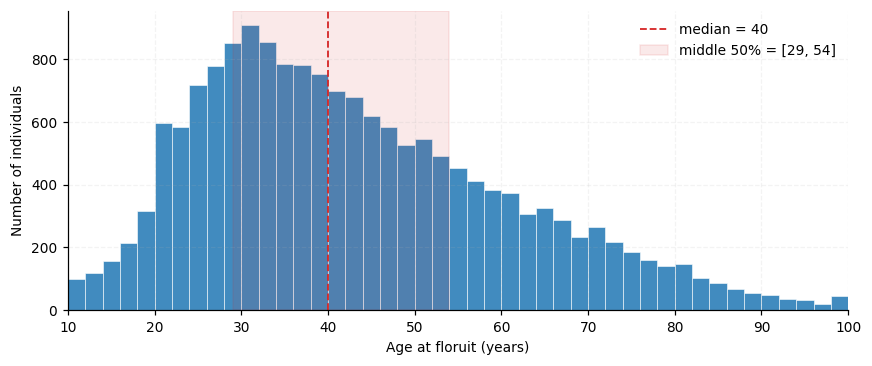

In [6]:
q = plausible['age_at_floruit']
med, q25, q75 = q.median(), q.quantile(0.25), q.quantile(0.75)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(q, bins=range(AGE_MIN, AGE_MAX + 1, 2),
        color='#2C7FB8', edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(med, color='#d62828', linestyle='--', linewidth=1.2, label=f'median = {med:.0f}')
ax.axvspan(q25, q75, color='#d62828', alpha=0.10, label=f'middle 50% = [{q25:.0f}, {q75:.0f}]')
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Number of individuals')
ax.set_xlim(AGE_MIN, AGE_MAX)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 2.1 Age distribution curves by historical era

One curve per era (KDE of age at floruit), so you can see whether the *typical* flourishing age shifts between Antiquity, the Middle Ages, the Early Modern period, the 19th century and the 20th–21st centuries.

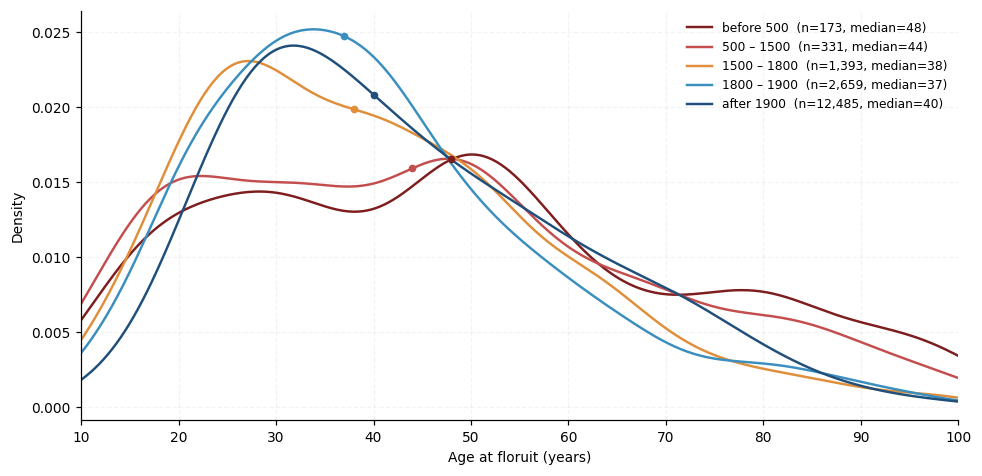

In [7]:
from scipy.stats import gaussian_kde

eras = [
    ('before 500',     None,  500),
    ('500 – 1500',      500, 1500),
    ('1500 – 1800',    1500, 1800),
    ('1800 – 1900',    1800, 1900),
    ('after 1900',     1900, None),
]

palette = ['#7e1d1d', '#c44e4e', '#e08e3a', '#3a8fbf', '#1f4f7a']

x_grid = np.linspace(AGE_MIN, AGE_MAX, 400)

fig, ax = plt.subplots(figsize=(9, 4.4))

for (label, lo, hi), color in zip(eras, palette):
    s = plausible['age_at_floruit']
    yr = plausible['floruit_year']
    mask = pd.Series(True, index=plausible.index)
    if lo is not None:
        mask &= yr >= lo
    if hi is not None:
        mask &= yr < hi
    sub = s[mask].values
    if len(sub) < 5:
        continue
    kde = gaussian_kde(sub, bw_method=0.25)
    y = kde(x_grid)
    med = float(np.median(sub))
    ax.plot(x_grid, y, color=color, linewidth=1.6,
            label=f'{label}  (n={len(sub):,}, median={med:.0f})')
    # mark median
    ax.plot([med], [kde(med)[0]], 'o', color=color, markersize=4, zorder=3)

ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

### 2.2 Does age at floruit depend on time?

Three tests on the year-precision sample:

- **Pearson r** — linear correlation between `floruit_year` and `age_at_floruit`.
- **Spearman ρ** — rank-based, robust to outliers and non-linear monotonic trends.
- **OLS regression** — `age ~ year`, with the slope expressed in *years of age per century*, plus 95% CI, p-value and R².

A small slope with a non-trivial p-value would mean: yes, time predicts age, but explains almost none of the variance — useful as a *signal* but not a strong predictor on its own.

In [8]:
from scipy import stats

x = plausible['floruit_year'].astype(float).values
y = plausible['age_at_floruit'].astype(float).values
n = len(x)

# Correlations
r_p,  p_p  = stats.pearsonr(x, y)
r_s,  p_s  = stats.spearmanr(x, y)

# OLS regression: age = a + b * year
lr = stats.linregress(x, y)
slope_per_century = lr.slope * 100
ci95 = 1.96 * lr.stderr
slope_ci_lo = (lr.slope - ci95) * 100
slope_ci_hi = (lr.slope + ci95) * 100
r2 = lr.rvalue ** 2

print(f'n = {n:,}')
print()
print('Pearson  r = {:+.3f}   p = {:.3g}'.format(r_p, p_p))
print('Spearman ρ = {:+.3f}   p = {:.3g}'.format(r_s, p_s))
print()
print('OLS  age = a + b · year')
print(f'  slope b           = {lr.slope:+.5f}  yr-of-age per yr-of-time')
print(f'  slope (per century) = {slope_per_century:+.2f}  [95% CI {slope_ci_lo:+.2f}, {slope_ci_hi:+.2f}]')
print(f'  intercept a       = {lr.intercept:+.2f}')
print(f'  R^2               = {r2:.4f}   (variance of age explained by year)')
print(f'  p-value (slope=0) = {lr.pvalue:.3g}')

n = 17,041

Pearson  r = +0.008   p = 0.296
Spearman ρ = +0.194   p = 1.87e-144

OLS  age = a + b · year
  slope b           = +0.00056  yr-of-age per yr-of-time
  slope (per century) = +0.06  [95% CI -0.05, +0.16]
  intercept a       = +41.66
  R^2               = 0.0001   (variance of age explained by year)
  p-value (slope=0) = 0.296


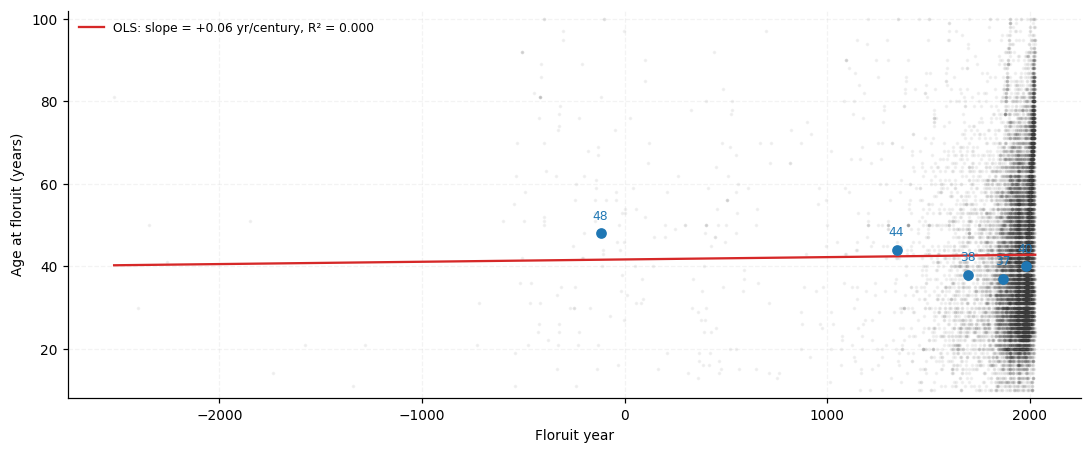

Per-era summary:
                 n  median  mean   q25   q75   std
era                                               
before 500     173    48.0  48.6  30.0  63.0  23.7
500 - 1500     331    44.0  45.3  26.5  59.5  22.5
1500 - 1800   1393    38.0  40.1  26.0  51.0  17.9
1800 - 1900   2659    37.0  40.0  28.0  49.0  17.2
after 1900   12485    40.0  43.4  30.0  55.0  17.6


In [9]:
# Per-era summary (median ± IQR + n) so the slope is interpretable
eras = [
    ('before 500',  None,  500),
    ('500 - 1500',   500, 1500),
    ('1500 - 1800', 1500, 1800),
    ('1800 - 1900', 1800, 1900),
    ('after 1900',  1900, None),
]
rows = []
for label, lo, hi in eras:
    m = pd.Series(True, index=plausible.index)
    if lo is not None: m &= plausible['floruit_year'] >= lo
    if hi is not None: m &= plausible['floruit_year'] <  hi
    sub = plausible.loc[m, 'age_at_floruit']
    if len(sub):
        rows.append({
            'era':    label,
            'n':      len(sub),
            'median': sub.median(),
            'mean':   sub.mean(),
            'q25':    sub.quantile(.25),
            'q75':    sub.quantile(.75),
            'std':    sub.std(),
        })
era_summary = pd.DataFrame(rows).set_index('era').round(1)
era_summary

# --- Scatter + regression line + per-era medians ---
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.scatter(x, y, s=2, color='#3a3a3a', alpha=0.05, rasterized=True)

xx = np.linspace(x.min(), x.max(), 100)
ax.plot(xx, lr.intercept + lr.slope * xx, color='#d62828', linewidth=1.5,
        label=f'OLS: slope = {slope_per_century:+.2f} yr/century, R² = {r2:.3f}')

for label, lo, hi in eras:
    m = pd.Series(True, index=plausible.index)
    if lo is not None: m &= plausible['floruit_year'] >= lo
    if hi is not None: m &= plausible['floruit_year'] <  hi
    sub_y = plausible.loc[m, 'age_at_floruit']
    sub_x = plausible.loc[m, 'floruit_year']
    if len(sub_y) >= 5:
        ax.plot([sub_x.median()], [sub_y.median()],
                'o', color='#1f77b4', markersize=6, zorder=4)
        ax.annotate(f'{sub_y.median():.0f}',
                    xy=(sub_x.median(), sub_y.median()),
                    xytext=(0, 7), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, color='#1f77b4')

ax.set_xlabel('Floruit year')
ax.set_ylabel('Age at floruit (years)')
ax.set_ylim(AGE_MIN - 2, AGE_MAX + 2)
ax.legend(frameon=False, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print('Per-era summary:')
print(era_summary.to_string())

### 2.3 Region as a random effect

The pure `age ~ year` model finds no signal. But continents differ in their typical flourishing age and in *which eras* they contribute data — that's a textbook setup for a mixed-effects model:

- **M0** — OLS: `age ~ year_c`  (baseline, pooled).
- **M1** — OLS: `age ~ year_c + C(macro_region)`  (region as a fixed effect — gives each continent its own intercept).
- **M2** — Mixed model: `age ~ year_c + (1 | macro_region)`  (region as a random intercept).

`year_c` = (`floruit_year` − 1900) / 100, so slopes are interpretable as **years of age per century**. From M2 we read off:
- the population-level slope of `year_c` (does time predict age once region is accounted for?),
- the variance attributable to region (`σ²_region`) vs residual (`σ²_resid`),
- the **ICC** = `σ²_region / (σ²_region + σ²_resid)` — the share of variance that lives *between* continents.

In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

dfm = plausible.dropna(subset=['macro_region']).copy()
dfm['year_c'] = (dfm['floruit_year'] - 1900) / 100.0
print(f'n (rows with continent): {len(dfm):,}   continents: {dfm["macro_region"].nunique()}')

# M0 — pooled OLS
m0 = smf.ols('age_at_floruit ~ year_c', data=dfm).fit()
print('\n=== M0: age ~ year_c ===')
print(f'  slope = {m0.params["year_c"]:+.3f} yr/century  '
      f'(95% CI [{m0.conf_int().loc["year_c", 0]:+.2f}, {m0.conf_int().loc["year_c", 1]:+.2f}]) '
      f'p = {m0.pvalues["year_c"]:.3g}')
print(f'  R^2 = {m0.rsquared:.4f}')

# M1 — region as fixed effect
m1 = smf.ols('age_at_floruit ~ year_c + C(macro_region)', data=dfm).fit()
print('\n=== M1: age ~ year_c + C(macro_region) ===')
print(f'  within-region slope of year_c = {m1.params["year_c"]:+.3f} yr/century  '
      f'p = {m1.pvalues["year_c"]:.3g}')
print(f'  R^2 = {m1.rsquared:.4f}   (region adds {m1.rsquared - m0.rsquared:+.4f})')
print('  ANOVA M0 vs M1 (does adding region improve fit?):')
print(sm.stats.anova_lm(m0, m1).round(4))

# M2 — random intercept by macro_region
m2 = smf.mixedlm('age_at_floruit ~ year_c', dfm, groups=dfm['macro_region']).fit(method='lbfgs')
print('\n=== M2: age ~ year_c + (1 | macro_region) ===')
sigma_r = float(np.asarray(m2.cov_re).ravel()[0])
sigma_e = float(m2.scale)
icc = sigma_r / (sigma_r + sigma_e)
print(f'  fixed slope of year_c = {m2.fe_params["year_c"]:+.3f} yr/century   '
      f'p = {m2.pvalues["year_c"]:.3g}')
print(f'  variance (region random intercept) = {sigma_r:.2f}')
print(f'  variance (residual)                = {sigma_e:.2f}')
print(f'  ICC = {icc:.3f}   <- share of variance between continents')

# Per-region random intercept (deviation from population mean)
print('\n  Random-intercept deviations per continent (sorted):')
re = pd.Series({k: float(v.iloc[0]) for k, v in m2.random_effects.items()}).sort_values()
for r, v in re.items():
    print(f'    {r:30s} {v:+.2f}')

n (rows with continent): 13,943   continents: 9

=== M0: age ~ year_c ===
  slope = +0.161 yr/century  (95% CI [+0.04, +0.29]) p = 0.0123
  R^2 = 0.0004

=== M1: age ~ year_c + C(macro_region) ===
  within-region slope of year_c = +0.214 yr/century  p = 0.00459
  R^2 = 0.0021   (region adds +0.0016)
  ANOVA M0 vs M1 (does adding region improve fit?):
   df_resid           ssr  df_diff    ss_diff       F  Pr(>F)
0   13941.0  4.433359e+06      0.0        NaN     NaN     NaN
1   13933.0  4.426201e+06      8.0  7157.7086  2.8164   0.004

=== M2: age ~ year_c + (1 | macro_region) ===
  fixed slope of year_c = +0.168 yr/century   p = 0.0109
  variance (region random intercept) = 0.99
  variance (residual)                = 317.65
  ICC = 0.003   <- share of variance between continents

  Random-intercept deviations per continent (sorted):
    Western Europe                 -0.77
    North America                  -0.67
    Asia                           -0.52
    Latin America                

/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


Per-continent OLS  age ~ year_c:
                 macro_region     n  mean_age  slope_per_century  slope_p    r2
        Ancient Mediterranean    49    43.061             -1.138    0.232 0.030
Middle-East and Africa (MENA)   106    43.934             -0.287    0.299 0.010
               Eastern Europe   744    45.703             -0.060    0.888 0.000
                         Asia   466    42.719              0.005    0.990 0.000
               Western Europe 10565    42.775              0.237    0.004 0.001
                North America  1468    42.841              1.158    0.006 0.005
                Latin America   246    42.976              5.408    0.011 0.026
                      Oceania   183    44.530              5.460    0.000 0.088
           Sub-Saharan Africa   116    43.586              6.894    0.033 0.039


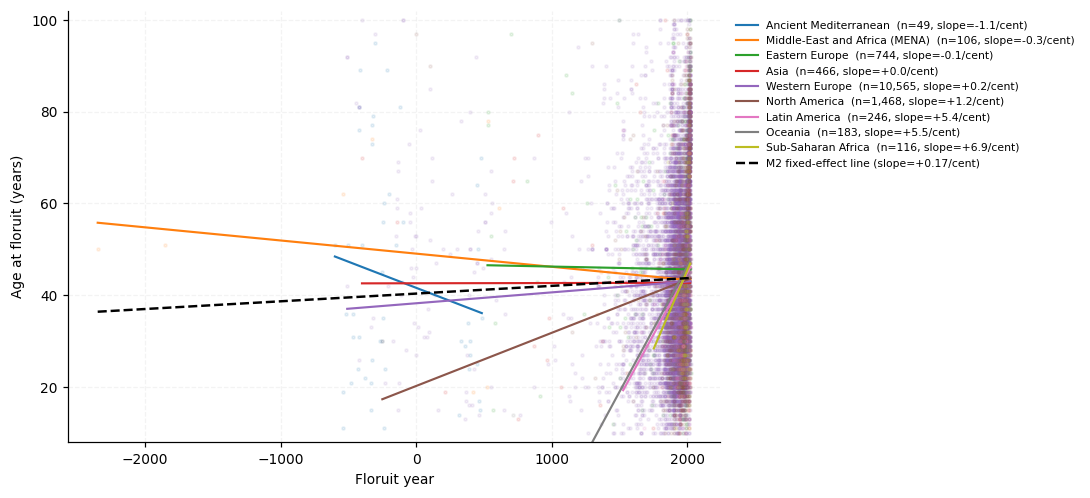

In [11]:
# Per-continent slopes — does the year-effect vary across regions?
per_region = []
for mr, sub in dfm.groupby('macro_region'):
    if len(sub) < 30:
        continue
    lr = stats.linregress(sub['year_c'].values, sub['age_at_floruit'].values)
    per_region.append({
        'macro_region': mr,
        'n': len(sub),
        'mean_age': sub['age_at_floruit'].mean(),
        'slope_per_century': lr.slope,
        'slope_p': lr.pvalue,
        'r2': lr.rvalue ** 2,
    })
per_region = pd.DataFrame(per_region).sort_values('slope_per_century').reset_index(drop=True)
print('Per-continent OLS  age ~ year_c:')
print(per_region.round(3).to_string(index=False))

# Visual: scatter colour-coded by continent, with one regression line per continent
fig, ax = plt.subplots(figsize=(10, 4.6))
cmap = plt.get_cmap('tab10')
for i, mr in enumerate(per_region['macro_region']):
    sub = dfm[dfm['macro_region'] == mr]
    ax.scatter(sub['floruit_year'], sub['age_at_floruit'],
               s=4, color=cmap(i % 10), alpha=0.10, rasterized=True)
    if len(sub) >= 30:
        lr = stats.linregress(sub['floruit_year'], sub['age_at_floruit'])
        xx = np.linspace(sub['floruit_year'].min(), sub['floruit_year'].max(), 50)
        ax.plot(xx, lr.intercept + lr.slope * xx,
                color=cmap(i % 10), linewidth=1.4,
                label=f'{mr}  (n={len(sub):,}, slope={lr.slope*100:+.1f}/cent)')

# Population fixed-effect line from M2
xx = np.linspace(dfm['floruit_year'].min(), dfm['floruit_year'].max(), 50)
yy = m2.fe_params['Intercept'] + m2.fe_params['year_c'] * (xx - 1900) / 100
ax.plot(xx, yy, color='black', linestyle='--', linewidth=1.6,
        label=f'M2 fixed-effect line (slope={m2.fe_params["year_c"]:+.2f}/cent)')

ax.set_xlabel('Floruit year')
ax.set_ylabel('Age at floruit (years)')
ax.set_ylim(AGE_MIN - 2, AGE_MAX + 2)
ax.legend(frameon=False, fontsize=7, loc='upper left',
          bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

### 3. Age at floruit through time (500-year bins)

In [12]:
plausible['bin'] = plausible['floruit_year'].map(bin_start)
plausible_t = plausible[(plausible['bin'] >= YEAR_MIN) & (plausible['bin'] <= YEAR_MAX)]

by_bin = (plausible_t.groupby('bin')['age_at_floruit']
                     .agg(['count', 'mean', 'median', 'std',
                           lambda s: s.quantile(.25),
                           lambda s: s.quantile(.75)])
                     .rename(columns={'<lambda_0>': 'q25', '<lambda_1>': 'q75'})
                     .reindex(bin_edges))
by_bin

,count,mean,median,std,q25,q75
bin,,,,,,
-3000,1.0,81.000000,81.0,NaN,81.0,81.00
-2500,3.0,40.333333,41.0,10.016653,35.5,45.50
-2000,3.0,28.666667,21.0,19.655364,17.5,36.00
-1500,2.0,16.000000,16.0,7.071068,13.5,18.50
-1000,13.0,51.846154,51.0,28.521472,31.0,70.00
-500,85.0,53.352941,51.0,24.440260,31.0,73.00
0,66.0,43.696970,46.5,20.630053,27.5,54.00
500,53.0,48.094340,53.0,21.256912,31.0,65.00
1000,278.0,44.730216,43.0,22.722050,26.0,58.75


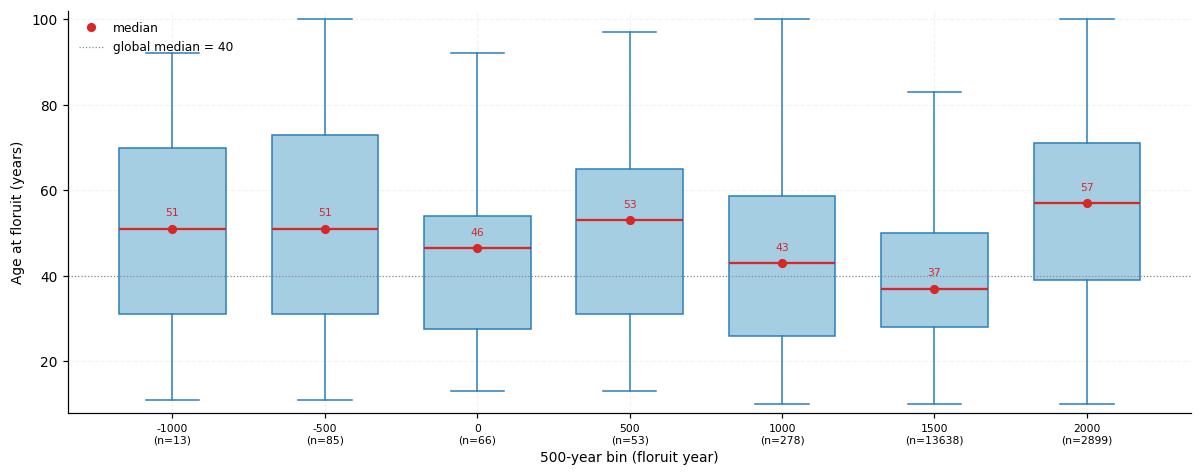

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.4))

data, positions, labels = [], [], []
for b in bin_edges:
    s = plausible_t.loc[plausible_t['bin'] == b, 'age_at_floruit']
    if len(s) >= 5:
        data.append(s.values)
        positions.append(b)
        labels.append(f'{b}\n(n={len(s)})')

ax.boxplot(data, positions=positions, widths=BIN_WIDTH * 0.7,
           showfliers=False, patch_artist=True,
           medianprops=dict(color='#d62828', linewidth=1.5),
           boxprops=dict(facecolor='#A6CEE3', edgecolor='#2C7FB8'),
           whiskerprops=dict(color='#2C7FB8'),
           capprops=dict(color='#2C7FB8'))

medians = [float(np.median(d)) for d in data]

# Red dot + value: median per box
ax.plot(positions, medians, 'o', color='#d62828', markersize=5,
        zorder=3, label='median')
for x, m in zip(positions, medians):
    ax.annotate(f'{m:.0f}', xy=(x, m), xytext=(0, 7), textcoords='offset points',
                ha='center', va='bottom', fontsize=7, color='#d62828')

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('Age at floruit (years)')
ax.set_xlabel('500-year bin (floruit year)')
ax.set_ylim(AGE_MIN - 2, AGE_MAX + 2)

global_med = plausible_t['age_at_floruit'].median()
ax.axhline(global_med, color='#888', linestyle=':', linewidth=0.8,
           label=f'global median = {global_med:.0f}')

ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

### 4. Age at floruit by continent

In [14]:
df_ac = plausible.dropna(subset=['macro_region']).copy()
order = (df_ac.groupby('macro_region')['age_at_floruit']
              .median().sort_values().index.tolist())

summary_c = (df_ac.groupby('macro_region')['age_at_floruit']
                  .agg(n='count', mean='mean', median='median', std='std',
                       q25=lambda s: s.quantile(.25),
                       q75=lambda s: s.quantile(.75))
                  .loc[order].round(1))
summary_c

,n,mean,median,std,q25,q75
macro_region,,,,,,
Ancient Mediterranean,49,43.1,35.0,23.8,24.0,60.0
Asia,466,42.7,38.0,19.7,27.0,56.0
Latin America,246,43.0,38.5,20.9,27.0,55.8
North America,1468,42.8,39.0,18.9,28.0,56.0
Western Europe,10565,42.8,40.0,17.2,30.0,54.0
Oceania,183,44.5,41.0,19.0,28.0,57.5
Sub-Saharan Africa,116,43.6,41.0,17.5,27.8,55.0
Middle-East and Africa (MENA),106,43.9,41.5,19.7,28.0,59.8
Eastern Europe,744,45.7,43.0,20.7,29.0,60.0


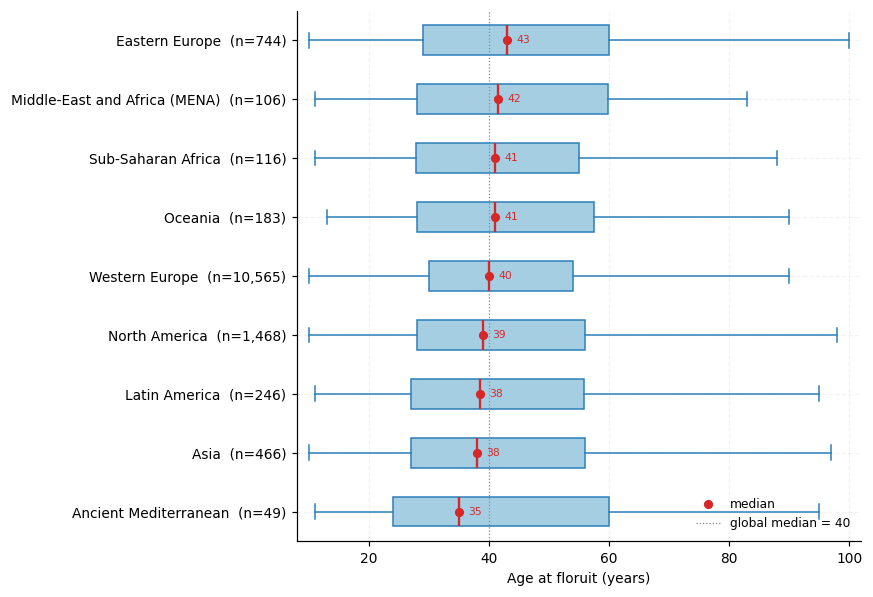

In [15]:
fig, ax = plt.subplots(figsize=(8, 0.5 * len(order) + 1))
data = [df_ac.loc[df_ac['macro_region'] == m, 'age_at_floruit'].values for m in order]
labels = [f'{m}  (n={len(d):,})' for m, d in zip(order, data)]

ax.boxplot(data, vert=False, tick_labels=labels, showfliers=False,
           patch_artist=True,
           medianprops=dict(color='#d62828', linewidth=1.5),
           boxprops=dict(facecolor='#A6CEE3', edgecolor='#2C7FB8'),
           whiskerprops=dict(color='#2C7FB8'),
           capprops=dict(color='#2C7FB8'))

medians = [float(np.median(d)) for d in data]
y_pos = list(range(1, len(order) + 1))

ax.plot(medians, y_pos, 'o', color='#d62828', markersize=5,
        zorder=3, label='median')
for y, m in zip(y_pos, medians):
    ax.annotate(f'{m:.0f}', xy=(m, y), xytext=(6, 0), textcoords='offset points',
                ha='left', va='center', fontsize=7, color='#d62828')

ax.set_xlabel('Age at floruit (years)')
ax.set_xlim(AGE_MIN - 2, AGE_MAX + 2)

global_med = df_ac['age_at_floruit'].median()
ax.axvline(global_med, color='#888', linestyle=':', linewidth=0.8,
           label=f'global median = {global_med:.0f}')

ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### 5. Median age at floruit \u2014 continent \u00d7 500-year bin

This is the table to **infer floruit** from a known birth year + continent.

In [16]:
df_act = plausible.dropna(subset=['macro_region']).copy()
med_pivot = (df_act.groupby(['macro_region', 'bin'])['age_at_floruit']
                   .median()
                   .unstack()
                   .reindex(columns=bin_edges))
n_pivot   = (df_act.groupby(['macro_region', 'bin']).size()
                   .unstack(fill_value=0)
                   .reindex(columns=bin_edges, fill_value=0))
med_pivot_masked = med_pivot.where(n_pivot >= 5)
med_pivot_masked.round(1)

bin,-3000,-2500,-2000,-1500,-1000,-500,0,500,1000,1500,2000,2500
macro_region,,,,,,,,,,,,
Ancient Mediterranean,NaN,NaN,NaN,NaN,NaN,51.0,29.5,NaN,NaN,NaN,NaN,NaN
Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,36.5,36.0,58.5,NaN
Eastern Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,52.0,38.0,65.0,NaN
Latin America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0,56.0,NaN
Middle-East and Africa (MENA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,49.0,NaN
North America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,35.0,65.0,NaN
Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,60.0,NaN
Sub-Saharan Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.0,47.0,NaN
Western Europe,NaN,NaN,NaN,NaN,NaN,50.0,47.0,52.0,40.0,38.0,58.0,NaN


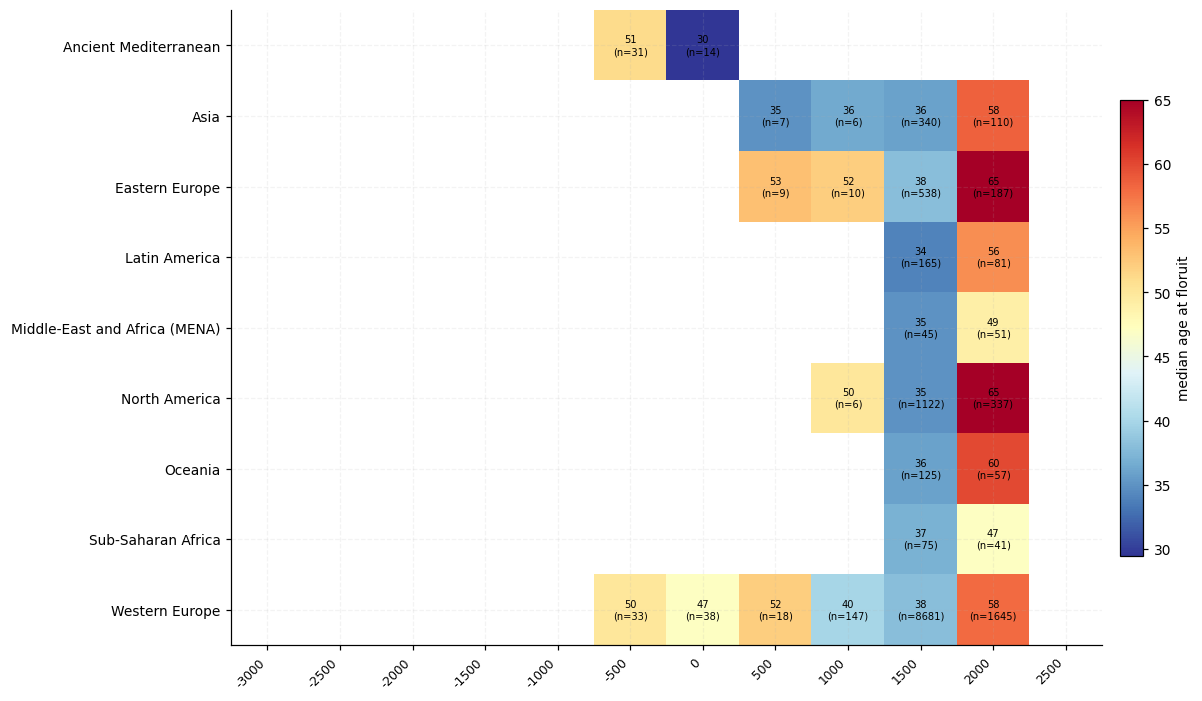

Saved -> paper/floruit_age_prior_continent_bin.csv


In [17]:
fig, ax = plt.subplots(figsize=(11, 0.55 * len(med_pivot_masked) + 1.5))
data = med_pivot_masked.values
vmin = np.nanmin(data) if np.isfinite(np.nanmin(data)) else 20
vmax = np.nanmax(data) if np.isfinite(np.nanmax(data)) else 60
im = ax.imshow(data, aspect='auto', cmap='RdYlBu_r', vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(bin_edges)))
ax.set_xticklabels([str(b) for b in bin_edges], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(med_pivot_masked.index)))
ax.set_yticklabels(med_pivot_masked.index, fontsize=9)
for i, mr in enumerate(med_pivot_masked.index):
    for j, b in enumerate(bin_edges):
        v = med_pivot_masked.iloc[i, j]
        n = n_pivot.iloc[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.0f}\n(n={n})', ha='center', va='center',
                    fontsize=6.5, color='black')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='median age at floruit')
plt.tight_layout()
plt.show()

med_pivot_masked.round(2).to_csv('floruit_age_prior_continent_bin.csv')
print('Saved -> paper/floruit_age_prior_continent_bin.csv')

### 6. Inference rule

For an individual with a birth year and a continent but no floruit:
```
floruit_year \u2248 birth_year + age_prior(continent, era_bin(birth_year))
```
Falling back to the global median (\u2248 41) when a `(continent, bin)` cell is too sparse.

## 7. Who adds the floruit property on Wikidata?

To understand the data-generating process behind P1317, we sample N floruit items, walk their revision histories via the MediaWiki API, and pick out revisions whose edit comment mentions `P1317` (Wikidata auto-includes the property ID in edit summaries when a statement is created/changed). Each such revision is attributed to a user, and we classify users as **bots** vs **humans** via the API's user-groups endpoint (a Wikidata bot has the `bot` group flag).

Caveats:
- Sampling — we look at ~1k random items, not all 69k.
- Bulk JSON edits *without* `P1317` in the auto-comment are missed; this slightly underestimates direct API edits but should be a small minority.
- A "P1317 edit" can be create, modify, remove, or rank/reference change — we treat them all as touches.

In [18]:
import os, json, requests, collections
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

N_SAMPLE = 2000
CACHE = '../data/all_humans/floruit_contributor_revisions.json'

WIKI_API = 'https://www.wikidata.org/w/api.php'
HEADERS = {'User-Agent': 'cultura_database/1.0 (research)'}


def fetch_history(qid):
    """For one item, return:
        creator        — username of the *first* revision (page creator)
        creator_ts     — timestamp of creation
        p1317_edits    — list of revisions whose comment mentions P1317
       Uses rvdir=newer so the first revision arrives first.
    """
    creator, creator_ts = None, None
    p1317 = []
    rvcontinue = None

    for _ in range(10):
        params = {
            'action': 'query',
            'prop': 'revisions',
            'titles': qid,
            'rvlimit': 500,
            'rvdir': 'newer',
            'rvprop': 'user|comment|timestamp|tags',
            'format': 'json',
        }
        if rvcontinue:
            params['rvcontinue'] = rvcontinue
        try:
            data = requests.get(WIKI_API, params=params, headers=HEADERS, timeout=30).json()
        except Exception:
            break

        for page in data.get('query', {}).get('pages', {}).values():
            for rev in page.get('revisions', []):
                if creator is None:
                    creator = rev.get('user')
                    creator_ts = rev.get('timestamp')
                comment = rev.get('comment') or ''
                if 'P1317' in comment:
                    p1317.append({
                        'user': rev.get('user'),
                        'timestamp': rev.get('timestamp'),
                        'comment': comment,
                        'tags': rev.get('tags', []),
                    })

        cont = data.get('continue', {}).get('rvcontinue')
        if not cont:
            break
        rvcontinue = cont

    return {
        'qid': qid,
        'creator': creator,
        'creator_ts': creator_ts,
        'p1317_edits': p1317,
    }


if os.path.exists(CACHE):
    with open(CACHE) as f:
        history = json.load(f)
    print(f'Loaded {len(history):,} cached items from {CACHE}')
else:
    conn = sqlite3.connect(DB)
    sample_qids = pd.read_sql(
        f'SELECT wikidata_id FROM individuals_floruit ORDER BY RANDOM() LIMIT {N_SAMPLE}',
        conn,
    )['wikidata_id'].tolist()
    conn.close()
    print(f'Sampling {len(sample_qids)} floruit items...')

    history = []
    with ThreadPoolExecutor(max_workers=12) as ex:
        futures = {ex.submit(fetch_history, q): q for q in sample_qids}
        for fut in tqdm(as_completed(futures), total=len(futures), desc='Fetching histories'):
            history.append(fut.result())

    os.makedirs(os.path.dirname(CACHE), exist_ok=True)
    with open(CACHE, 'w') as f:
        json.dump(history, f)
    print(f'Saved {len(history):,} items -> {CACHE}')

n_with_creator = sum(1 for h in history if h['creator'])
n_p1317 = sum(len(h['p1317_edits']) for h in history)
print()
print(f'Items in sample:                 {len(history):,}')
print(f'Items with a creator captured:   {n_with_creator:,}')
print(f'Total P1317-mentioning edits:    {n_p1317:,}')
print(f'Items with at least one such:    {sum(1 for h in history if h["p1317_edits"]):,}'
      f'  ({sum(1 for h in history if h["p1317_edits"]) / len(history):.1%})')

Loaded 2,000 cached items from ../data/all_humans/floruit_contributor_revisions.json

Items in sample:                 2,000
Items with a creator captured:   20
Total P1317-mentioning edits:    14
Items with at least one such:    10  (0.5%)


/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
import re

def is_anon_ip(name):
    if not name:
        return False
    if re.match(r'^\d{1,3}(\.\d{1,3}){3}$', name):  # IPv4
        return True
    if ':' in name and re.match(r'^[0-9A-Fa-f:]+$', name):  # IPv6
        return True
    return False


def looks_like_bot(name):
    if not name:
        return False
    n = name.lower()
    return n.endswith('bot') or n.startswith('bot') or 'bot' in n.split('_') or 'bot' in n.split('-')


def get_user_groups(users, batch=50):
    out = {}
    users = [u for u in users if u and not is_anon_ip(u)]
    for i in range(0, len(users), batch):
        b = users[i:i + batch]
        try:
            r = requests.get(WIKI_API, params={
                'action': 'query',
                'list': 'users',
                'ususers': '|'.join(b),
                'usprop': 'groups',
                'format': 'json',
            }, headers=HEADERS, timeout=30).json()
        except Exception:
            continue
        for u in r.get('query', {}).get('users', []):
            out[u['name']] = u.get('groups', [])
    return out


# Build set of all users we ever saw (creators + p1317-edit users)
all_users = {h['creator'] for h in history if h['creator']}
for h in history:
    for r in h['p1317_edits']:
        if r.get('user'):
            all_users.add(r['user'])

named_users = [u for u in all_users if not is_anon_ip(u)]
groups = get_user_groups(named_users)


def classify(user):
    if not user:
        return 'unknown'
    if is_anon_ip(user):
        return 'anonymous IP'
    g = groups.get(user, [])
    if 'bot' in g or looks_like_bot(user):
        return 'bot'
    return 'human'


# --- Item creators ---
creator_counts = collections.Counter(h['creator'] for h in history if h['creator'])
creators_df = (pd.DataFrame({'user': list(creator_counts.keys()),
                             'items_created': list(creator_counts.values())})
                 .assign(type=lambda d: d['user'].map(classify))
                 .sort_values('items_created', ascending=False)
                 .reset_index(drop=True))

print('=== ITEM CREATORS ===  (who first created the floruit Q-item)')
share_creators = creators_df.groupby('type')['items_created'].sum().sort_values(ascending=False)
total_c = share_creators.sum()
for t, n in share_creators.items():
    print(f'  {t:14s} {n:6,}  ({n / total_c:6.1%})')
print()
print('Top 15 item creators:')
print(creators_df.head(15).to_string(index=False))

# --- P1317-statement editors ---
p1317_users = [r['user'] for h in history for r in h['p1317_edits'] if r.get('user')]
p1317_counts = collections.Counter(p1317_users)
p1317_df = (pd.DataFrame({'user': list(p1317_counts.keys()),
                          'p1317_edits': list(p1317_counts.values())})
              .assign(type=lambda d: d['user'].map(classify))
              .sort_values('p1317_edits', ascending=False)
              .reset_index(drop=True))

print()
print('=== DIRECT P1317 EDITORS ===  (revisions whose comment mentions P1317)')
share_p1317 = p1317_df.groupby('type')['p1317_edits'].sum().sort_values(ascending=False)
total_p = share_p1317.sum() if len(p1317_df) else 0
for t, n in share_p1317.items():
    print(f'  {t:14s} {n:6,}  ({n / total_p:6.1%})')
print()
print('Top 15 direct floruit editors:')
print(p1317_df.head(15).to_string(index=False))

=== ITEM CREATORS ===  (who first created the floruit Q-item)
  human              16  ( 80.0%)
  bot                 4  ( 20.0%)

Top 15 item creators:
          user  items_created  type
     Hannolans              6 human
     Infopetal              2 human
    Ambrosia10              1 human
  Karl Oblique              1 human
GZWDer (flood)              1 human
      Finoskov              1 human
     Emijrpbot              1   bot
      BeneBot*              1 human
     Kresspahl              1 human
       Sk!dbot              1   bot
        Dzahsh              1 human
      HuskyBot              1   bot
    Sweet kate              1 human
     MerlIwBot              1   bot

=== DIRECT P1317 EDITORS ===  (revisions whose comment mentions P1317)
  human              10  ( 71.4%)
  bot                 4  ( 28.6%)

Top 15 direct floruit editors:
            user  p1317_edits  type
  BotMultichillT            4   bot
        Finoskov            2 human
       Hannolans           

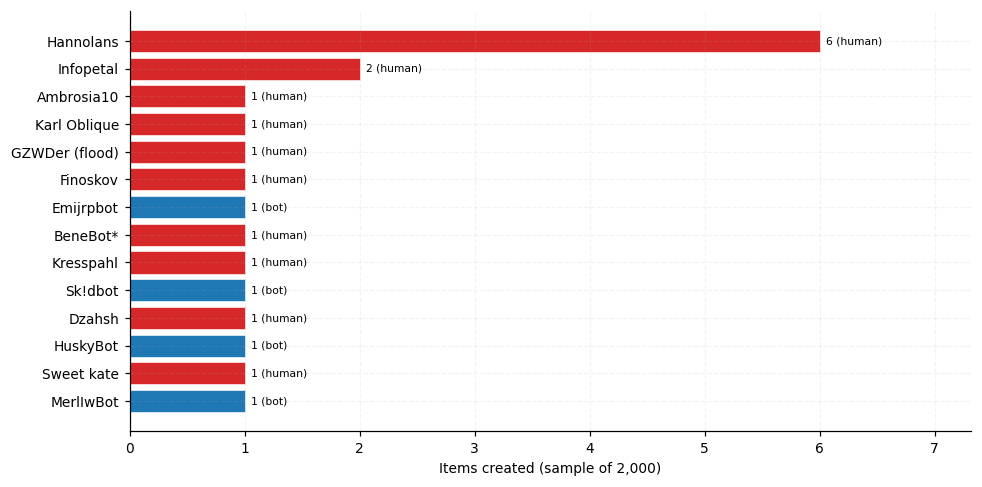

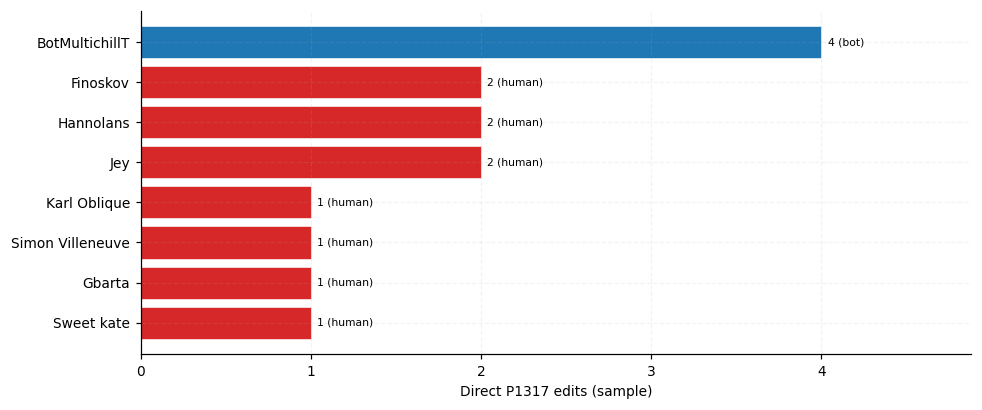

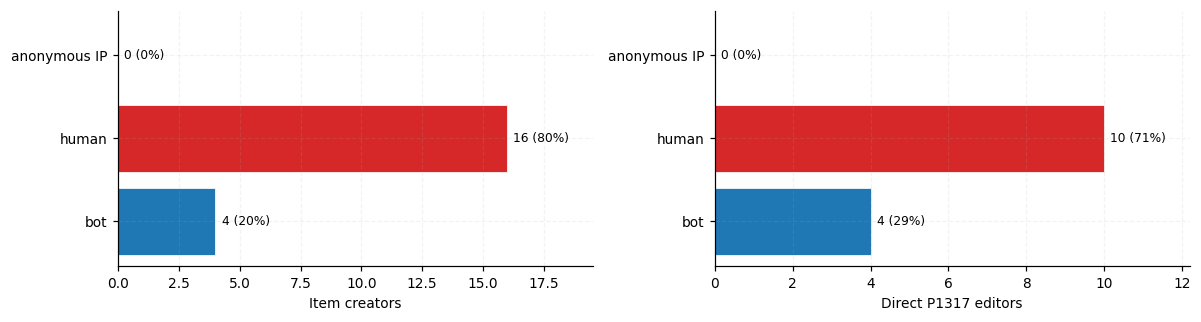

In [20]:
type_color = {'bot': '#1f77b4', 'human': '#d62828',
              'anonymous IP': '#808080', 'unknown': '#cccccc'}

def barh_top(ax, df, value_col, title):
    top = df.head(15).iloc[::-1]
    ax.barh(top['user'], top[value_col],
            color=[type_color.get(t, '#cccccc') for t in top['type']],
            edgecolor='white', linewidth=0.4)
    for y, (n, t) in enumerate(zip(top[value_col], top['type'])):
        ax.annotate(f'{n:,} ({t})', xy=(n, y), xytext=(4, 0),
                    textcoords='offset points', va='center', fontsize=7)
    ax.set_xlabel(title)
    ax.margins(x=0.22)


# Top item creators
fig, ax = plt.subplots(figsize=(9, 4.5))
barh_top(ax, creators_df, 'items_created', 'Items created (sample of {:,})'.format(len(history)))
plt.tight_layout()
plt.show()

# Top direct P1317 editors (if any)
if len(p1317_df):
    fig, ax = plt.subplots(figsize=(9, min(4.5, 0.35 * min(len(p1317_df), 15) + 1)))
    barh_top(ax, p1317_df, 'p1317_edits', 'Direct P1317 edits (sample)')
    plt.tight_layout()
    plt.show()

# Bot vs human breakdown — both views side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
order = ['bot', 'human', 'anonymous IP']
for ax, share, title in [(axes[0], share_creators, 'Item creators'),
                          (axes[1], share_p1317,    'Direct P1317 editors')]:
    vals = [int(share.get(t, 0)) for t in order]
    tot = sum(vals)
    ax.barh(order, vals, color=[type_color[t] for t in order],
            edgecolor='white', linewidth=0.5)
    for y, v in enumerate(vals):
        pct = v / tot if tot else 0
        ax.annotate(f'{v:,} ({pct:.0%})', xy=(v, y), xytext=(4, 0),
                    textcoords='offset points', va='center', fontsize=8)
    ax.set_xlabel(title)
    ax.margins(x=0.22)
plt.tight_layout()
plt.show()

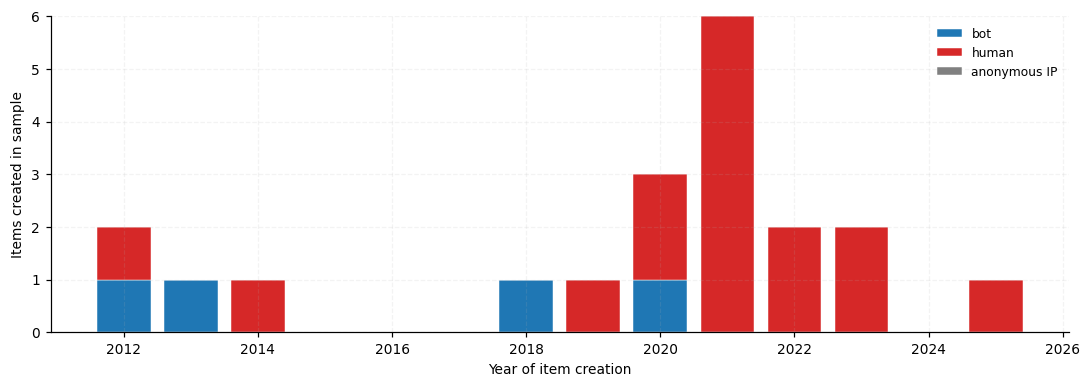

Example direct P1317 edit-comments (first 100 chars):
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 1875
      1  /* wbsetreference-add:2| */ [[Property:P1317]]: 1875
      1  /* wbcreateclaim-create:1| */ [[Property:P1317]]: 1945, #quickstatements; #temporary_batch_164948938
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 16. century
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 17. century
      1  /* wbsetclaim-update:2||1|1 */ [[Property:P1317]]: 17. century
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 1994
      1  /* wbsetreference-add:2| */ [[Property:P1317]]: 1994
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 2015, Add floruit
      1  /* wbsetclaim-create:2||1 */ [[Property:P1317]]: 2011, Add floruit


In [21]:
creator_df = pd.DataFrame([{
    'user': h['creator'],
    'ts': h['creator_ts'],
} for h in history if h['creator']])
creator_df['ts']   = pd.to_datetime(creator_df['ts'])
creator_df['year'] = creator_df['ts'].dt.year
creator_df['type'] = creator_df['user'].map(classify)

by_year = (creator_df.groupby(['year', 'type']).size()
                     .unstack(fill_value=0)
                     .reindex(columns=['bot', 'human', 'anonymous IP'], fill_value=0)
                     .sort_index())

fig, ax = plt.subplots(figsize=(10, 3.6))
bottom = np.zeros(len(by_year))
for t in ['bot', 'human', 'anonymous IP']:
    ax.bar(by_year.index, by_year[t].values, bottom=bottom,
           color=type_color[t], edgecolor='white', linewidth=0.3, label=t)
    bottom += by_year[t].values
ax.set_xlabel('Year of item creation')
ax.set_ylabel('Items created in sample')
ax.legend(frameon=False, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# Show example edit-comment patterns where P1317 is explicit
all_p1317 = [r for h in history for r in h['p1317_edits']]
if all_p1317:
    print('Example direct P1317 edit-comments (first 100 chars):')
    samples = (pd.Series([r['comment'][:100] for r in all_p1317])
                 .value_counts().head(10))
    for c, n in samples.items():
        print(f'  {n:5d}  {c}')